<a href="https://colab.research.google.com/github/14marcos1/pesquisa_quimica_2026/blob/main/liliarizacao001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Centróide estimado na ROI: (348.1, 212.3)
Área da região escolhida: 16230.0
Compacidade: 0.384


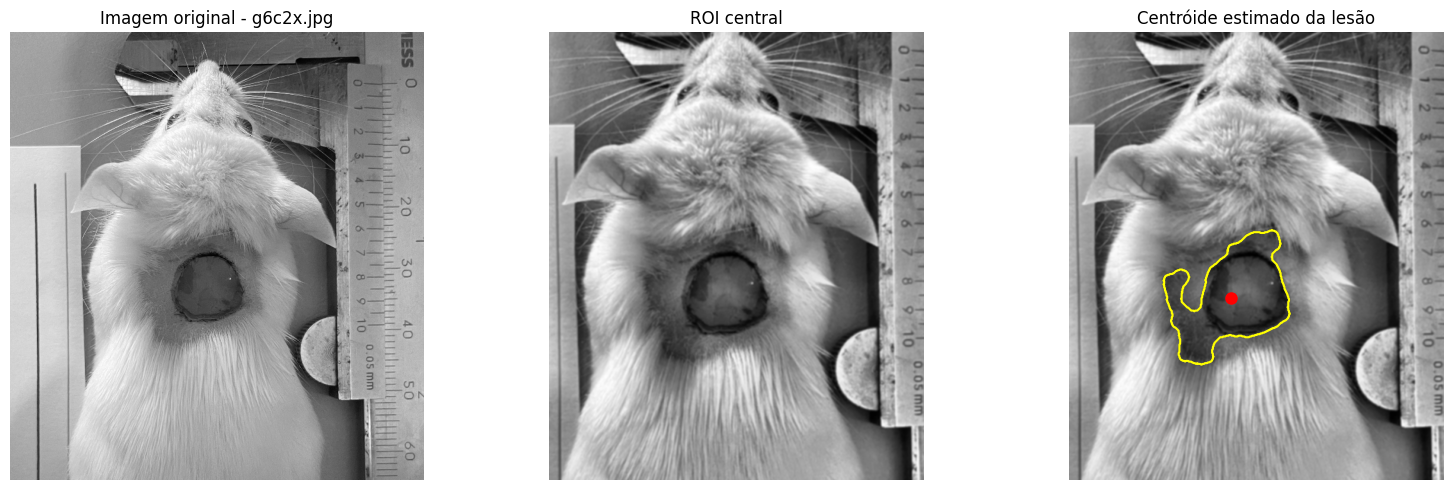

In [10]:
# BLOCO ÚNICO — centróide da lesão na imagem g6c2x.jpg

!pip install -q opencv-python scikit-image scipy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure, morphology

# =========================================================
# 1. CARREGAR IMAGEM
# =========================================================
img = cv2.imread('g6c2x.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Imagem 'g6c2x.jpg' não encontrada. Faça upload no Colab.")

# reduzir tamanho para não pesar
h0, w0 = img.shape
escala = 700 / max(h0, w0)
if escala < 1:
    img = cv2.resize(img, (int(w0 * escala), int(h0 * escala)))

# =========================================================
# 2. PRÉ-PROCESSAMENTO
# =========================================================
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_eq = clahe.apply(img)

img_blur = cv2.GaussianBlur(img_eq, (5, 5), 0)

# ROI central
h, w = img_blur.shape
margem_x = int(w * 0.12)
margem_y = int(h * 0.08)

img_roi = img_blur[margem_y:h-margem_y, margem_x:w-margem_x]

# =========================================================
# 3. REGIÃO DE BUSCA DA LESÃO
# =========================================================
h_roi, w_roi = img_roi.shape

yc1, yc2 = int(h_roi * 0.30), int(h_roi * 0.78)
xc1, xc2 = int(w_roi * 0.20), int(w_roi * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# =========================================================
# 4. LIMIARIZAÇÃO + LIMPEZA MORFOLÓGICA
# =========================================================
th = filters.threshold_otsu(busca)

# lesão tende a ser mais escura
mask = busca < (th * 0.68)

mask = morphology.remove_small_objects(mask, min_size=1500)
mask = morphology.remove_small_holes(mask, area_threshold=2000)
mask = morphology.binary_opening(mask, morphology.disk(8))
mask = morphology.binary_closing(mask, morphology.disk(9))

# =========================================================
# 5. ESCOLHER REGIÃO MAIS PLAUSÍVEL
# =========================================================
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada. Ajuste o threshold ou os parâmetros morfológicos.")

centro_ref = np.array([mask.shape[0] / 2, mask.shape[1] / 2])

candidatos = []
for r in regs:
    per = r.perimeter if r.perimeter > 0 else 1
    comp = 4 * np.pi * r.area / (per ** 2)
    dist = np.linalg.norm(np.array(r.centroid) - centro_ref)

    score = dist - 200 * comp
    candidatos.append((score, r))

candidatos.sort(key=lambda x: x[0])
melhor = candidatos[0][1]

# =========================================================
# 6. CENTRÓIDE FINAL
# =========================================================
cy, cx = melhor.centroid

cy_full = cy + yc1
cx_full = cx + xc1

print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Área da região escolhida: {melhor.area}')
print(f'Compacidade: {4 * np.pi * melhor.area / (melhor.perimeter ** 2 + 1e-8):.3f}')

# =========================================================
# 7. VISUALIZAÇÃO
# =========================================================
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagem original - g6c2x.jpg')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_roi, cmap='gray')
plt.title('ROI central')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_roi, cmap='gray')
plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)
plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.title('Centróide estimado da lesão')
plt.axis('off')

plt.tight_layout()
plt.show()

Centro da elipse: (348.1, 212.3)
Semi-eixos estimados: rx=95.4, ry=101.8


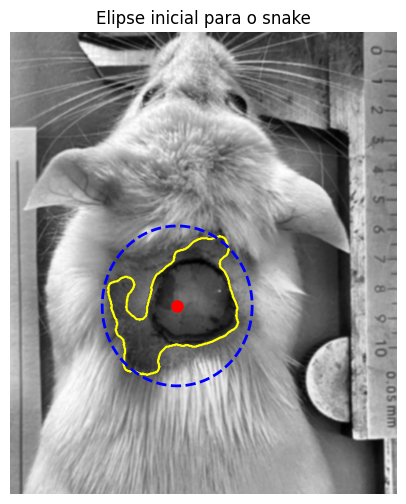

In [11]:
# BLOCO 4 — gerar elipse inicial automática para o snake

import numpy as np
import matplotlib.pyplot as plt

# usar a região escolhida no bloco anterior
minr, minc, maxr, maxc = melhor.bbox

# centro da elipse = centróide da região escolhida
cy, cx = melhor.centroid

# semi-eixos com pequena expansão
ry = (maxr - minr) / 2 * 1.15
rx = (maxc - minc) / 2 * 1.15

# gerar pontos da elipse
t = np.linspace(0, 2 * np.pi, 120)
y_init = cy + ry * np.sin(t)
x_init = cx + rx * np.cos(t)

# converter para coordenadas da img_roi
y_init_full = y_init + yc1
x_init_full = x_init + xc1

print(f'Centro da elipse: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Semi-eixos estimados: rx={rx:.1f}, ry={ry:.1f}')

# visualizar
plt.figure(figsize=(6, 6))
plt.imshow(img_roi, cmap='gray')

# contorno amarelo da máscara escolhida
plt.contour(
    labels == melhor.label,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

# centróide
plt.plot(cx_full, cy_full, 'ro', markersize=8)

# elipse inicial
plt.plot(x_init_full, y_init_full, '--b', linewidth=2)

plt.title('Elipse inicial para o snake')
plt.axis('off')
plt.show()